# Data preparation and bond descriptors

This notebook parses the ATcT spreadsheet, separates molecules from atoms and
atomic ions, retrieves PubChem identifiers and SMILES, and constructs the
bond-count descriptor table used by the machine-learning notebooks.

**Main input:** `../data/thermochemical_acta.xlsx`

**Main output:** `../data/ATcT_bonds_corrected.csv`

> The PubChem lookup cells require internet access. The processed CSV files
> included in this repository can be used directly when structure retrieval
> is not repeated.


## 1. Parse the thermochemical Excel workbook


In [109]:
from collections import Counter
from pathlib import Path
import re
import time
import warnings
from rdkit import Chem

import numpy as np
import pandas as pd

In [3]:
COLUMNS = [
    "species_name",
    "formula",
    "_unused1",
    "image",
    "dHf_0K",
    "dHf_298K",
    "uncertainty",
    "units",
    "_unused2",
    "molar_mass_raw",
    "atct_id",
]
 
def read_atct_excel(path, sheet_name=0, header_rows=3):
    raw = pd.read_excel(path, 
                        sheet_name=sheet_name, 
                        header=None,
                        skiprows=header_rows, 
                        engine="openpyxl")
    raw = raw.iloc[:, :len(COLUMNS)]
    raw.columns = COLUMNS
 
    raw["record_id"] = raw["species_name"].notna().cumsum()
 
    def merge_record(group):
        out = {}
        for col in group.columns:
            vals = [str(v).strip() for v in group[col].dropna()]
            out[col] = " ".join(vals) if vals else np.nan
        return pd.Series(out)
 
    records = (raw.groupby("record_id", sort=True)
                  .apply(merge_record, include_groups=False)
                  .reset_index(drop=True))
 
    mass_parts = records["molar_mass_raw"].str.split("±", expand=True)
    records["molar_mass"] = pd.to_numeric(mass_parts[0].str.strip(), errors="coerce")
    records["molar_mass_uncertainty"] = (
        pd.to_numeric(mass_parts[1].str.strip(), errors="coerce")
        if mass_parts.shape[1] > 1 else np.nan
    )
 
  
    id_parts = records["atct_id"].str.extract(r"([\d\-]+)\*(\d+)")
    records["cas_number"] = id_parts[0]
    records["atct_seq"] = pd.to_numeric(id_parts[1], errors="coerce")
 

    for col in ["dHf_0K", "dHf_298K"]:
        records[col] = pd.to_numeric(records[col], errors="coerce")
    records["uncertainty_kJmol"] = pd.to_numeric(
        records["uncertainty"].replace("exact", "0"), errors="coerce"
    )
 
    records = records.drop(columns=["_unused1", "_unused2", "image",
                                     "molar_mass_raw", "uncertainty"])
    return records
 
 
if __name__ == "__main__":
    df = read_atct_excel("../data/thermochemical_acta.xlsx")   # <- point this at your real file
    print(df.head())
    print(df.dtypes)

  species_name       formula  dHf_0K  dHf_298K units        atct_id  \
0   Dihydrogen        H2 (g)     0.0       0.0   NaN    1333-74-0*0   
1       Helium        He (g)     0.0       0.0   NaN    7440-59-7*0   
2        Boron      B (cr,l)     0.0       0.0   NaN  7440-42-8*500   
3       Carbon  C (graphite)     0.0       0.0   NaN  7440-44-0*500   
4   Dinitrogen        N2 (g)     0.0       0.0   NaN    7727-37-9*0   

   molar_mass  molar_mass_uncertainty cas_number  atct_seq  uncertainty_kJmol  
0    2.015880                0.000140  1333-74-0         0                0.0  
1    4.002602                0.000002  7440-59-7         0                0.0  
2   10.811000                0.007000  7440-42-8       500                0.0  
3   12.010700                0.000800  7440-44-0       500                0.0  
4   28.013480                0.000140  7727-37-9         0                0.0  
species_name                  str
formula                       str
dHf_0K                   

In [4]:
atct = df

required = ["species_name", "formula", "dHf_298K", "atct_id", "molar_mass"]
missing_required = atct[required].isna().sum()
if missing_required.any():
    raise ValueError(f"Missing required ATcT values:\n{missing_required[missing_required > 0]}")
if atct["atct_id"].duplicated().any():
    raise ValueError("ATcT identifiers are not unique after parsing.")

print(f"Parsed records: {len(atct):,}")
display(atct.head())


Parsed records: 3,442


,species_name,formula,dHf_0K,dHf_298K,units,atct_id,molar_mass,molar_mass_uncertainty,cas_number,atct_seq,uncertainty_kJmol
0,Dihydrogen,H2 (g),0.0,0.0,NaN,1333-74-0*0,2.015880,0.000140,1333-74-0,0,0.0
1,Helium,He (g),0.0,0.0,NaN,7440-59-7*0,4.002602,0.000002,7440-59-7,0,0.0
2,Boron,"B (cr,l)",0.0,0.0,NaN,7440-42-8*500,10.811000,0.007000,7440-42-8,500,0.0
3,Carbon,C (graphite),0.0,0.0,NaN,7440-44-0*500,12.010700,0.000800,7440-44-0,500,0.0
4,Dinitrogen,N2 (g),0.0,0.0,NaN,7727-37-9*0,28.013480,0.000140,7727-37-9,0,0.0


## 2. Separate molecules from monatomic atoms and ions


In [6]:
def classify_species(formula):
    """
    Classify an ATcT formula as:
        - molecule
        - atom_or_ion
        - electron
        - unknown

    Returns
    -------
    tuple
        (species_type, number_of_atoms, cleaned_formula)
    """

    if pd.isna(formula):
        return "unknown", np.nan, None

    text = str(formula).strip()

    text = re.split(r"\s+\(", text, maxsplit=1)[0].strip()

    if re.fullmatch(r"e(?:lectron)?[+-]?", text, flags=re.IGNORECASE):
        return "electron", 0, text

    text = re.sub(r"\^?[+-]\d*$", "", text).strip()

    cleaned_formula = text

    periodic_table = Chem.GetPeriodicTable()

    def is_element(symbol):
        if symbol in {"D", "T"}:
            return True

        try:
            return periodic_table.GetAtomicNumber(symbol) > 0
        except (RuntimeError, ValueError):
            return False

    tokens = re.findall(
        r"[A-Z][a-z]?|\d+|[()\[\]{}]",
        cleaned_formula
    )

    stack = [0]
    i = 0

    while i < len(tokens):
        token = tokens[i]

        if token in {"(", "[", "{"}:
            stack.append(0)
            i += 1

        elif token in {")", "]", "}"}:
            if len(stack) == 1:
                i += 1
                continue

            group_atoms = stack.pop()
            i += 1

            multiplier = 1
            if i < len(tokens) and tokens[i].isdigit():
                multiplier = int(tokens[i])
                i += 1

            stack[-1] += group_atoms * multiplier

        elif is_element(token):
            i += 1

            multiplier = 1
            if i < len(tokens) and tokens[i].isdigit():
                multiplier = int(tokens[i])
                i += 1

            stack[-1] += multiplier

        else:
            i += 1

    while len(stack) > 1:
        stack[-2] += stack.pop()

    number_of_atoms = stack[0]

    if number_of_atoms == 0:
        species_type = "unknown"
    elif number_of_atoms == 1:
        species_type = "atom_or_ion"
    else:
        species_type = "molecule"

    return species_type, number_of_atoms, cleaned_formula


In [9]:
classification = df["formula"].apply(classify_species)

df[
    ["species_type", "number_of_atoms", "cleaned_formula"]
] = pd.DataFrame(
    classification.tolist(),
    index=df.index
)

molecules = df[
    df["species_type"] == "molecule"
].copy()

atoms_ions = df[
    df["species_type"].isin(["atom_or_ion", "electron"])
].copy()

unknown = df[
    df["species_type"] == "unknown"
].copy()

print(f"Total species : {len(df)}")
print(f"Molecules     : {len(molecules)}")
print(f"Atoms/Ions    : {len(atoms_ions)}")
print(f"Unknown       : {len(unknown)}")

Total species : 3442
Molecules     : 3268
Atoms/Ions    : 174
Unknown       : 0


In [10]:
molecules.to_csv(
    "../data/ATcT_molecules.csv",
    index=False
)

atoms_ions.to_csv(
    "../data/ATcT_atoms_ions.csv",
    index=False
)

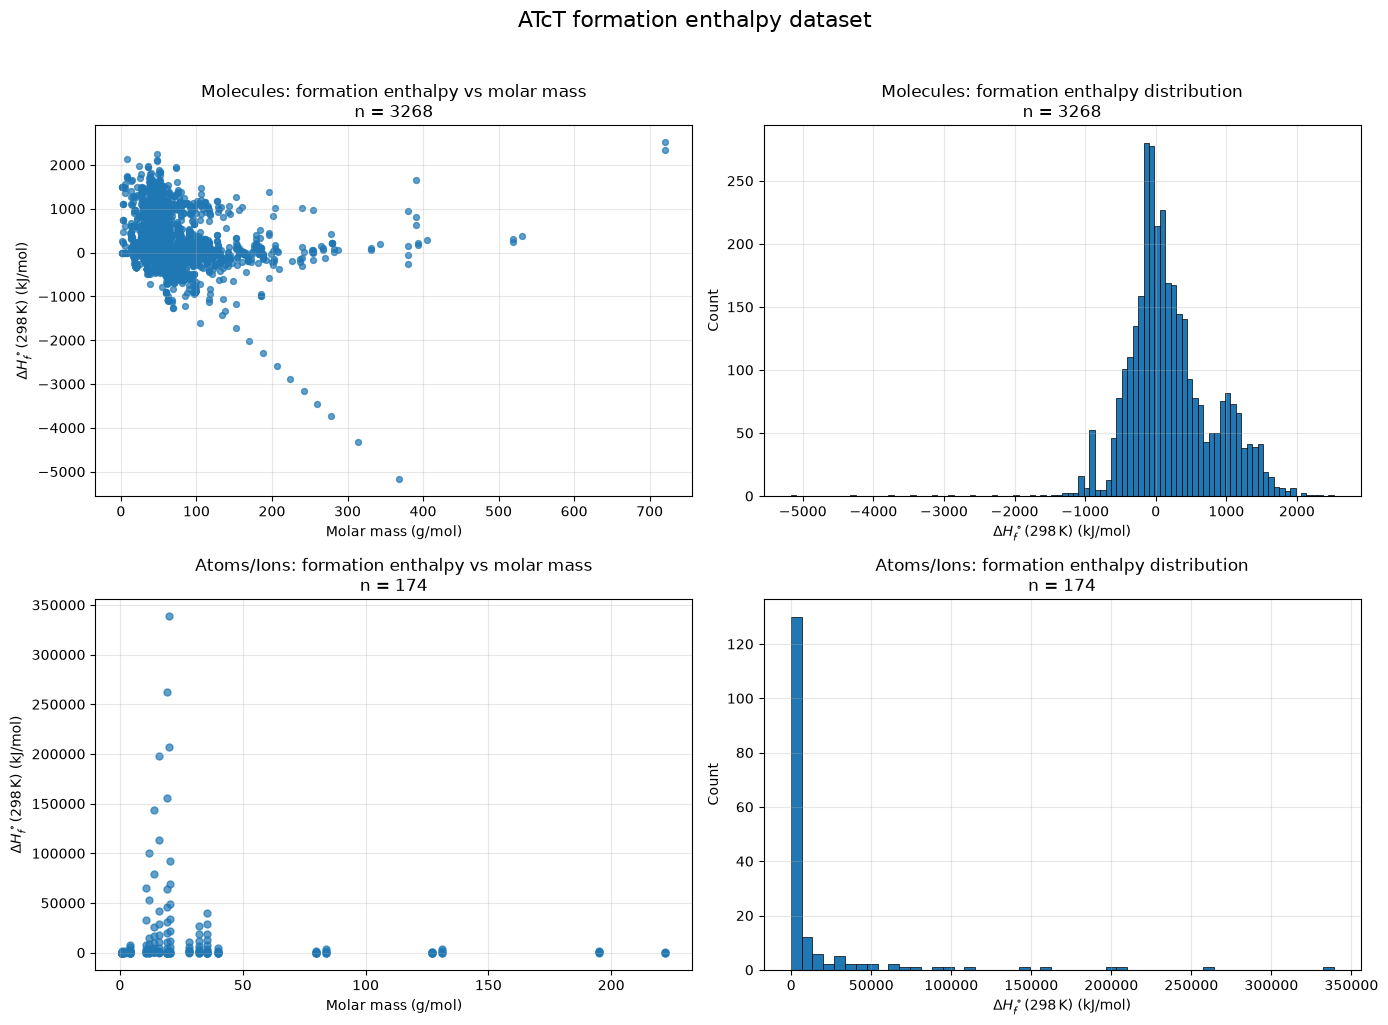

In [110]:
import matplotlib.pyplot as plt

target = "dHf_298K"

mol_plot = molecules.copy()
atom_ion_plot = atoms_ions.copy()

for data in (mol_plot, atom_ion_plot):
    data["molar_mass"] = pd.to_numeric(
        data["molar_mass"],
        errors="coerce"
    )

    data[target] = pd.to_numeric(
        data[target],
        errors="coerce"
    )

mol_plot = mol_plot.dropna(
    subset=["molar_mass", target]
)

atom_ion_plot = atom_ion_plot.dropna(
    subset=["molar_mass", target]
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# =========================================================
# 1. Molecules: scatter plot
# =========================================================
axes[0, 0].scatter(
    mol_plot["molar_mass"],
    mol_plot[target],
    s=18,
    alpha=0.7
)

axes[0, 0].set_title(
    f"Molecules: formation enthalpy vs molar mass\n"
    f"n = {len(mol_plot)}"
)

axes[0, 0].set_xlabel("Molar mass (g/mol)")
axes[0, 0].set_ylabel(
    r"$\Delta H_f^\circ(298\,\mathrm{K})$ (kJ/mol)"
)
axes[0, 0].grid(alpha=0.3)


# =========================================================
# 2. Molecules: histogram
# =========================================================
axes[0, 1].hist(
    mol_plot[target],
    bins=100,
    edgecolor="black",
    linewidth=0.5
)

axes[0, 1].set_title(
    f"Molecules: formation enthalpy distribution\n"
    f"n = {len(mol_plot)}"
)

axes[0, 1].set_xlabel(
    r"$\Delta H_f^\circ(298\,\mathrm{K})$ (kJ/mol)"
)
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)


# =========================================================
# 3. Atoms and ions: scatter plot
# =========================================================
axes[1, 0].scatter(
    atom_ion_plot["molar_mass"],
    atom_ion_plot[target],
    s=25,
    alpha=0.7
)

axes[1, 0].set_title(
    f"Atoms/Ions: formation enthalpy vs molar mass\n"
    f"n = {len(atom_ion_plot)}"
)

axes[1, 0].set_xlabel("Molar mass (g/mol)")
axes[1, 0].set_ylabel(
    r"$\Delta H_f^\circ(298\,\mathrm{K})$ (kJ/mol)"
)
axes[1, 0].grid(alpha=0.3)


# =========================================================
# 4. Atoms and ions: histogram
# =========================================================
axes[1, 1].hist(
    atom_ion_plot[target],
    bins=50,
    edgecolor="black",
    linewidth=0.5
)

axes[1, 1].set_title(
    f"Atoms/Ions: formation enthalpy distribution\n"
    f"n = {len(atom_ion_plot)}"
)

axes[1, 1].set_xlabel(
    r"$\Delta H_f^\circ(298\,\mathrm{K})$ (kJ/mol)"
)
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(alpha=0.3)


fig.suptitle(
    "ATcT formation enthalpy dataset",
    fontsize=16,
    y=1.02
)

fig.savefig(
    "ATcT_formation_enthalpy.jpg",
    format="jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

## 3. Basic composition descriptors

This section performs simple composition checks before structural identifiers
and bond descriptors are introduced.


In [16]:
from sklearn import linear_model
from chemml.preprocessing import ConstantColumns, Outliers

pre_columns = molecules.columns
X = molecules.loc[:, (molecules != molecules.iloc[0]).any()]
print(X.shape)
print('removed columns: ', [i for i in pre_columns if i not in X.columns])

(3268, 13)
removed columns:  ['species_type']


In [17]:
X = molecules[["molar_mass"]]
y = molecules[["dHf_298K"]]

Xy = pd.concat([X,y], axis = 1)
print(Xy.shape)
print(Xy.head())

(3268, 2)
    molar_mass  dHf_298K
0     2.015880       0.0
4    28.013480       0.0
5    31.998800       0.0
6    37.996806       0.0
10   70.905400       0.0


In [18]:
Xy_corr = Xy.corr(method='pearson')
print(Xy_corr.shape)
Xy_corr.tail(n = 10)


(2, 2)


,molar_mass,dHf_298K
molar_mass,1.000000,-0.186296
dHf_298K,-0.186296,1.000000


In [19]:
Xy_corr[y.columns[0]].sort_values(ascending=False).head(n = 10)

dHf_298K      1.000000
molar_mass   -0.186296
Name: dHf_298K, dtype: float64

In [20]:
def atom_counts(formula):
    """
    Return a dictionary with the number of each atom in a molecular formula.
    Example: C2H6O -> {'C':2, 'H':6, 'O':1}
    """
    atoms = {}

    matches = re.findall(r"([A-Z][a-z]?)(\d*)", formula)

    for element, count in matches:
        count = int(count) if count else 1
        atoms[element] = atoms.get(element, 0) + count

    return atoms

In [21]:
atom_data = molecules["formula"].apply(atom_counts)
print(atom_data.tail())

3426    {'He': 2}
3427    {'Cl': 2}
3430     {'N': 2}
3431     {'H': 2}
3433     {'O': 2}
Name: formula, dtype: object


In [23]:
atom_features = pd.DataFrame(atom_data.tolist()).fillna(0)
X = pd.concat(
    [
        molecules[["molar_mass"]],
        atom_features
    ],
    axis=1
)

y = molecules["dHf_298K"]

In [24]:
Xy = pd.concat([X,y], axis = 1)
print(Xy.shape)
print(Xy.head())

(3419, 30)
    molar_mass    H    N    O    F   Cl   Br    I    D    C  ...   Kr   Ar  \
0     2.015880  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
4    28.013480  0.0  0.0  0.0  0.0  2.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
5    31.998800  0.0  0.0  0.0  0.0  0.0  2.0  0.0  0.0  0.0  ...  0.0  0.0   
6    37.996806  0.0  0.0  0.0  0.0  0.0  0.0  2.0  0.0  0.0  ...  0.0  0.0   
10   70.905400  0.0  0.0  2.0  0.0  0.0  0.0  0.0  0.0  1.0  ...  0.0  0.0   

     Xe   Td    E   Ry   Pt   Pi   Ci  dHf_298K  
0   0.0  0.0  0.0  0.0  0.0  0.0  0.0       0.0  
4   0.0  0.0  0.0  0.0  0.0  0.0  0.0       0.0  
5   0.0  0.0  0.0  0.0  0.0  0.0  0.0       0.0  
6   0.0  0.0  0.0  0.0  0.0  0.0  0.0       0.0  
10  0.0  0.0  0.0  0.0  0.0  0.0  0.0       0.0  

[5 rows x 30 columns]


In [48]:
def number_of_elements(formula):
    elements = re.findall(r"[A-Z][a-z]?", str(formula))
    return len(elements)

# Count elements in each formula
molecules["number_of_elements"] = molecules["formula"].apply(number_of_elements)

# Select single-atom species
single_atom = molecules[molecules["number_of_elements"] == 1]

print(f"Number of single-atom species: {len(single_atom)}")

print(
    single_atom[["species_name", "formula"]]
    .to_string(index=True)
)

Number of single-atom species: 82
                   species_name                formula
0                    Dihydrogen                 H2 (g)
1                    Dinitrogen                 N2 (g)
2                      Dioxygen                 O2 (g)
3                    Difluorine                 F2 (g)
4                    Dichlorine                Cl2 (g)
5                     Dibromine             Br2 (cr,l)
6                      Diiodine              I2 (cr,l)
7            Deuterium molecule                 D2 (g)
81                    Dibromine                Br2 (g)
82                     Diiodine                 I2 (g)
141          Trihydrogen cation              [H3]+ (g)
244             Dioxygen cation              [O2]+ (g)
245                  Ethynylene                 C2 (g)
283                    Disulfur                 S2 (g)
329              Dioxygen anion              [O2]- (g)
468           Dinitrogen cation              [N2]+ (g)
493                  Dichloride

## 4. Retrieve PubChem identifiers and SMILES

The lookup is performed in stages so that unresolved records can be retried
using CAS numbers, names, formulas, and neutral analogues.


In [54]:
from rdkit import Chem
from collections import Counter
import pubchempy as pcp
import time

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [51]:
def get_pubchem_data(cas):

    time.sleep(0.2)

    try:
        compounds = pcp.get_compounds(str(cas), "name")

        if not compounds:
            return pd.Series([None]*4)

        c = compounds[0]

        return pd.Series([
            c.cid,
            c.connectivity_smiles,
            c.isomeric_smiles,
            c.inchi
        ])

    except Exception:
        return pd.Series([None]*4)
        

In [52]:
import signal
import pubchempy as pcp

class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException()

signal.signal(signal.SIGALRM, timeout_handler)

def get_info(cas):
    try:
        # Timeout after 60 seconds
        signal.alarm(60)

        compound = pcp.get_compounds(str(cas), "name")[0]

        # Cancel the alarm
        signal.alarm(0)

        return (
            compound.cid,
            compound.canonical_smiles,
            compound.isomeric_smiles,
            compound.inchi
        )

    except TimeoutException:
        print(f"Timeout: {cas}")
        return None, None, None, None

    except Exception:
        signal.alarm(0)
        return None, None, None, None

In [53]:
cid = []
canonical = []
isomeric = []
inchi = []

n = len(molecules)

for i, cas in enumerate(molecules["species_name"], start=1):

    print(f"{i:5d}/{n}   CAS = {cas}")

    c, s1, s2, inc = get_info(cas)

    cid.append(c)
    canonical.append(s1)
    isomeric.append(s2)
    inchi.append(inc)

    # Save every 100 molecules
    if i % 100 == 0 or i == n:

        temp = molecules.iloc[:i].copy()

        temp["CID"] = cid
        temp["Canonical_SMILES"] = canonical
        temp["Isomeric_SMILES"] = isomeric
        temp["InChI"] = inchi

        temp.to_csv("ATcT_pubchem_progress.csv", index=False)

        print(f" ---> Saved progress ({i}/{n})")

#-----------------------------------------------------------
# Save final file
#-----------------------------------------------------------

molecules["CID"] = cid
molecules["Canonical_SMILES"] = canonical
molecules["Isomeric_SMILES"] = isomeric
molecules["InChI"] = inchi

molecules.to_csv("ATcT_pubchem_complete.csv", index=False)

print("\nFinished!")

    1/3268   CAS = Dihydrogen
    2/3268   CAS = Dinitrogen
    3/3268   CAS = Dioxygen
    4/3268   CAS = Difluorine
    5/3268   CAS = Dichlorine
    6/3268   CAS = Dibromine
    7/3268   CAS = Diiodine
    8/3268   CAS = Deuterium molecule
    9/3268   CAS = Methane
   10/3268   CAS = Water
   11/3268   CAS = Carbon dioxide
   12/3268   CAS = Water
   13/3268   CAS = Ethane
   14/3268   CAS = Ethylene
   15/3268   CAS = Propane
   16/3268   CAS = Methyl
   17/3268   CAS = Methanol
   18/3268   CAS = Ammonia
   19/3268   CAS = Hydroxyl
   20/3268   CAS = Formaldehyde
   21/3268   CAS = Carbon monoxide
   22/3268   CAS = Acetylene
   23/3268   CAS = Ethanol
   24/3268   CAS = Hydrogen chloride
   25/3268   CAS = Benzene
   26/3268   CAS = Propene
   27/3268   CAS = Hydrogen fluoride
   28/3268   CAS = Ethyl
   29/3268   CAS = Hydrogen cyanide
   30/3268   CAS = Hydrogen bromide
   31/3268   CAS = Nitric oxide
   32/3268   CAS = Methylamine
   33/3268   CAS = Acetaldehyde
   34/3268   

/tmp/ipykernel_7071/1853738691.py:24: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  compound.canonical_smiles,
/tmp/ipykernel_7071/1853738691.py:25: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  compound.isomeric_smiles,


  458/3268   CAS = Hydroxysilyl
  459/3268   CAS = Trimethylsilanol
  460/3268   CAS = 2-Aminoethyl
  461/3268   CAS = 2-Propanamine
  462/3268   CAS = Hydrosulfide
  463/3268   CAS = Sulfuric acid
  464/3268   CAS = Carbonyl sulfide
  465/3268   CAS = Mercaptooxy
  466/3268   CAS = Sulfeno
  467/3268   CAS = Chloro hypochlorite
  468/3268   CAS = Hydroperoxonium
  469/3268   CAS = Dinitrogen cation
  470/3268   CAS = Carbon dioxide cation
  471/3268   CAS = Nitroxyl
  472/3268   CAS = Hydrazino
  473/3268   CAS = Nitryl hydride
  474/3268   CAS = Oxoniumyl ion
  475/3268   CAS = Chlorooxy hypochlorite
  476/3268   CAS = Chlorine pentafluoride
  477/3268   CAS = Hydrogen isocyanide cation
  478/3268   CAS = Cyanomethanide
  479/3268   CAS = Methyloxonium
  480/3268   CAS = n-Propylide
  481/3268   CAS = Allyl anion
  482/3268   CAS = Propargylenide
  483/3268   CAS = 2-Butyn-1-yl anion
  484/3268   CAS = Cycloheptatriene
  485/3268   CAS = n-Octane
  486/3268   CAS = Ethoxy
  487/3268 

/tmp/ipykernel_7071/1853738691.py:24: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  compound.canonical_smiles,
/tmp/ipykernel_7071/1853738691.py:25: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  compound.isomeric_smiles,


  505/3268   CAS = Chloromethoxy
  506/3268   CAS = Fluorotrichloromethane
  507/3268   CAS = Formyl chloride
  508/3268   CAS = 2-Chloroethanol
  509/3268   CAS = Butadiynyl
  510/3268   CAS = o-Benzyne
  511/3268   CAS = m-Toluoyl
  512/3268   CAS = Iodobenzene
  513/3268   CAS = Furan
  514/3268   CAS = 1-Hydroxy-1-methylethyl
  515/3268   CAS = Trifluoroethene
  516/3268   CAS = Isocyanoethene
  517/3268   CAS = 1-Isocyanoethylidene
  518/3268   CAS = 2-Cyanovinyl
  519/3268   CAS = 3-Methylene-1-cyclopropen-1-yl
  520/3268   CAS = Oxosilylene
  521/3268   CAS = Silyloxy anion
  522/3268   CAS = Cyclobutyl
  523/3268   CAS = 1-Ethynyl-2-propyn-1-yl
  524/3268   CAS = 1-Propanamine
  525/3268   CAS = Sulfurous acid
  526/3268   CAS = Sulfo
  527/3268   CAS = Dioxygen
  528/3268   CAS = Boric acid
  529/3268   CAS = Dioxodiazoxane
  530/3268   CAS = Trioxidane
  531/3268   CAS = Nitric acid
  532/3268   CAS = Isodiazene
  533/3268   CAS = Oxoammoniumyl
  534/3268   CAS = 2-Hydrotriox

...

 3003/3268   CAS = Diazomethyl
 3004/3268   CAS = Trioxidane
 3005/3268   CAS = 2-Ethylidenedioxidan-2-ium-1-ide
 3006/3268   CAS = Hydrogen iodide
 3007/3268   CAS = Hydrogen iodide
 3008/3268   CAS = Nitrous oxide
 3009/3268   CAS = Hydrogen chloride
 3010/3268   CAS = Hydrogen chloride
 3011/3268   CAS = Diazomethyl
 3012/3268   CAS = Disulfur anion
 3013/3268   CAS = 1-Methylethenyl hydroperoxide
 3014/3268   CAS = 2-Iodoethanol
 3015/3268   CAS = Sulfonyl cation
 3016/3268   CAS = Sulfur dioxide
 3017/3268   CAS = Acetic acid
 3018/3268   CAS = Hydrodioxonitrate
 3019/3268   CAS = Ethylideneoxoniumyloxy
 3020/3268   CAS = Hydrogen fluoride
 3021/3268   CAS = Vinyl hydroperoxide
 3022/3268   CAS = 1-Methylethylidene
 3023/3268   CAS = Sulfur trioxide cation
 3024/3268   CAS = Hydrogen bromide
 3025/3268   CAS = Sulfite
 3026/3268   CAS = Diazomethylium
 3027/3268   CAS = 1,3,5-Hexatriyne cation
 3028/3268   CAS = Sulfur oxide peroxide
 3029/3268   CAS = Nitric acid
 3030/3268   CAS

/tmp/ipykernel_7071/1853738691.py:24: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  compound.canonical_smiles,
/tmp/ipykernel_7071/1853738691.py:25: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  compound.isomeric_smiles,


 3106/3268   CAS = Hydrogen bromide
 3107/3268   CAS = Fulvenallene
 3108/3268   CAS = Ammonium hydroxide
 3109/3268   CAS = Acetate
 3110/3268   CAS = Benzocyclopropene
 3111/3268   CAS = Cycloheptatetraene
 3112/3268   CAS = Trioxidaniumyl
 3113/3268   CAS = Acetic acid
 3114/3268   CAS = 1,3-Propanediyl
 3115/3268   CAS = Sulfur hydroxide oxide
 3116/3268   CAS = Sulfur hydroxide oxide
 3117/3268   CAS = Sulfur hydroxide oxide cation
 3118/3268   CAS = Sulfur hydroxide oxide cation
 3119/3268   CAS = Chlorine chlorite
 3120/3268   CAS = Isocyanoamidogen
 3121/3268   CAS = Sulfurous acid
 3122/3268   CAS = Sulfurous acid
 3123/3268   CAS = Isocyanoamidogen
 3124/3268   CAS = Isocyanoamidogen
 3125/3268   CAS = 2-Methyliumylidynehydrazin-2-ium-1-ide
 3126/3268   CAS = Sulfite
 3127/3268   CAS = Sulfurous acid
 3128/3268   CAS = Sulfurous acid
 3129/3268   CAS = Sulfurous acid
 3130/3268   CAS = Sulfurous acid
 3131/3268   CAS = Sulfurous acid
 3132/3268   CAS = Sulfurous acid
 3133/32

/tmp/ipykernel_7071/1853738691.py:24: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  compound.canonical_smiles,
/tmp/ipykernel_7071/1853738691.py:25: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  compound.isomeric_smiles,


 3203/3268   CAS = Oxonium
 3204/3268   CAS = Diazirenide
 3205/3268   CAS = Hydrogen iodide
 3206/3268   CAS = Platinum dimer cation
 3207/3268   CAS = Platinum dimer anion
 3208/3268   CAS = Acetic acid
 3209/3268   CAS = 2-Cyclopropyn-1-ylidene
 3210/3268   CAS = C=O-C cation
 3211/3268   CAS = Hydroxyaminylium
 3212/3268   CAS = Hydrogen bromide
 3213/3268   CAS = trans-Cycloheptene
 3214/3268   CAS = Propylidene
 3215/3268   CAS = Hydrogen fluoride
 3216/3268   CAS = (Formyloxy)methyl
 3217/3268   CAS = 1-Hydroxyethenylium
 3218/3268   CAS = Tetrafluorohydrazine cation
 3219/3268   CAS = 2-Butynylium
 3220/3268   CAS = Hydrogen bromide
 3221/3268   CAS = Nitrilomethylimidogen
 3222/3268   CAS = Iminomethylimidogen anion
 3223/3268   CAS = Ethynol
 3224/3268   CAS = Hypochloroperoxoous acid, hydroxy ester
 3225/3268   CAS = Dihydroxymethylium
 3226/3268   CAS = Hydrogen chloride
 3227/3268   CAS = Carboxymethyl
 3228/3268   CAS = Hydrogen chloride
 3229/3268   CAS = Oxirane
 3230/3

In [92]:
print("Total molecules:", len(molecules))
print("Have CID:", molecules["CID"].notna().sum())
print("No CID:", molecules["CID"].isna().sum())

Total molecules: 3268
Have CID: 3210
No CID: 58


In [93]:
def get_charge(formula):

    if pd.isna(formula):
        return None

    formula = str(formula)

    # Match charges like +, -, 2+, 3-, etc.
    m = re.search(r'(\d*)([+-])', formula)

    if m is None:
        return 0

    magnitude = int(m.group(1)) if m.group(1) else 1

    if m.group(2) == "+":
        return magnitude
    else:
        return -magnitude

In [94]:
def neutral_formula(formula):

    formula = str(formula)

    # Remove state
    formula = re.sub(r"\s*\(.*\)", "", formula)

    # Remove brackets
    formula = formula.replace("[","").replace("]","")

    # Remove charges
    formula = re.sub(r"\d*[+-]", "", formula)

    return formula


In [95]:
missing = molecules["Canonical_SMILES"].isna()

In [96]:
for idx in molecules[missing].index:

    formula = neutral_formula(molecules.loc[idx, "formula"])

    try:

        results = pcp.get_compounds(formula, "formula")

        if results:

            comp = results[0]

            molecules.loc[idx, "CID"] = comp.cid
            molecules.loc[idx, "Canonical_SMILES"] = comp.connectivity_smiles
            molecules.loc[idx, "Isomeric_SMILES"] = comp.smiles
            molecules.loc[idx, "InChI"] = comp.inchi

            print(
                f"{molecules.loc[idx,'species_name']}  --->  {comp.connectivity_smiles}"
            )

    except Exception:

        pass

Trifluoride ion  --->  [F-]
Trifluorine cation  --->  [F-]


In [56]:
def clean_formula(formula):

    if pd.isna(formula):
        return None

    formula = str(formula)

    # Remove thermochemical state information
    # CH3OO (g, gauche) -> CH3OO
    formula = re.sub(r"\s*\(.*\)", "", formula)

    # Remove brackets
    formula = formula.replace("[", "")
    formula = formula.replace("]", "")

    # Remove charge symbols
    formula = re.sub(r"[+-]", "", formula)

    # Remove spaces
    formula = formula.replace(" ", "")

    return formula


def clean_name(name):

    if pd.isna(name):
        return None

    # Remove states: (g), (g, trans), etc.
    name = re.sub(r"\s*\(.*\)", "", str(name))

    return name.strip()



def search_pubchem(row):

    cas = str(row["cas_number"])
    name = clean_name(row["species_name"])
    formula = clean_formula(row["formula"])

    queries = [
        (cas, "name"),
        (name, "name"),
        (formula, "formula")
    ]

    for query, namespace in queries:

        try:

            results = pcp.get_compounds(query, namespace)

            if not results:
                continue


            # For formula searches, try to find the matching formula
            if namespace == "formula":

                for comp in results:

                    if comp.molecular_formula == formula:
                        results = [comp]
                        break


            comp = results[0]

            print(f"Found {query} -> CID {comp.cid}")


            return pd.Series({
                "CID": comp.cid,
                "Canonical_SMILES": comp.connectivity_smiles,
                "Isomeric_SMILES": comp.smiles,
                "InChI": comp.inchi,
            })


        except Exception as e:

            print(f"Error searching '{query}' ({namespace})")
            print(e)


    return pd.Series({
        "CID": None,
        "Canonical_SMILES": None,
        "Isomeric_SMILES": None,
        "InChI": None,
    })

In [90]:
import os

total = missing.sum()
count = 0

for idx in molecules[missing].index:

    count += 1

    print(f"{count}/{total} : {molecules.loc[idx,'species_name']}")

    molecules.loc[idx,
        ["CID",
         "Canonical_SMILES",
         "Isomeric_SMILES",
         "InChI"]] = search_pubchem(molecules.loc[idx])

    # Save every 50 molecules
    if count % 50 == 0 or count == total:

        molecules.to_csv(
            "../data/ATcT_with_pubchem_updated.csv",
            index=False
        )

        found = molecules["CID"].notna().sum()

        print(f"Saved. Found {found}/{len(molecules)} compounds.")

1/58 : Protonated oxirane
Error searching '' (formula)
identifier/cid cannot be None
2/58 : Chloromethylidyne
Error searching 'CCl' (formula)
PubChem HTTP Error 400 PUGREST.BadRequest: Failed to get any CID(s) from URL path or POST data
3/58 : t-Butyl anion
Error searching '' (formula)
identifier/cid cannot be None
4/58 : Trimethylsiloxide
Error searching '' (formula)
identifier/cid cannot be None
5/58 : Bifluoride
Error searching '' (formula)
identifier/cid cannot be None
6/58 : Water anion
Error searching '' (formula)
identifier/cid cannot be None
7/58 : Hydrogen difluoride
Error searching '' (formula)
identifier/cid cannot be None
8/58 : Isoformyl anion
Error searching '' (formula)
identifier/cid cannot be None
9/58 : Oxygen cation monohydrate
Error searching '' (formula)
identifier/cid cannot be None
10/58 : t-Butylium
Error searching '' (formula)
identifier/cid cannot be None
11/58 : 2-Hydroxy-1,1-dimethylethyl
Error searching '' (formula)
identifier/cid cannot be None
12/58 : COC

In [97]:
found = molecules["CID"].notna().sum()
not_found = molecules["CID"].isna().sum()

print(f"Found: {found}")
print(f"Not found: {not_found}")
print(f"Success rate: {100*found/len(molecules):.2f}%")

Found: 3212
Not found: 56
Success rate: 98.29%


In [98]:
found = molecules["CID"].notna().sum()

missing_inchi = (
    molecules["CID"].notna() &
    molecules["InChI"].isna()
).sum()

In [99]:
missing = molecules[molecules["Canonical_SMILES"].isna()]
print(len(missing))
print(
    missing[
        ["species_name","formula"]
    ].to_string()
)

56
                           species_name                        formula
422                  Protonated oxirane              [(CH2CH2)OH]+ (g)
502                   Chloromethylidyne                        CCl (g)
640                       t-Butyl anion                 [(CH3)3C]- (g)
696                   Trimethylsiloxide               [(CH3)3SiO]- (g)
741                          Bifluoride        [(HF)(F)]- (g, singlet)
795                         Water anion          [(H)(OH)]- (g, vdW ?)
800                 Hydrogen difluoride               (F)(HF) (g, lin)
852                     Isoformyl anion  [(CO)(H)]- (g, vdW singlet ?)
855           Oxygen cation monohydrate                  [(HOH)O]+ (g)
864                          t-Butylium                 [(CH3)3C]+ (g)
868         2-Hydroxy-1,1-dimethylethyl               (CH3)2CCH2OH (g)
882                             COC vdW           (CO)(C) (g, triplet)
885                            Oxywater                     (H2O)O (g)
925

## 5. Generate RDKit bond-count descriptors

Canonical SMILES are converted to RDKit molecular graphs. Bond counts are
stored using element-pair and bond-order labels such as `C-O_D`.

In [100]:
def get_bond_types(smiles):

    # Handle missing values
    if pd.isna(smiles):
        return Counter()

    # Make sure it's a string
    smiles = str(smiles)

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return Counter()

    mol = Chem.AddHs(mol)

    counter = Counter()

    bond_map = {
        "SINGLE": "S",
        "DOUBLE": "D",
        "TRIPLE": "T",
        "AROMATIC": "A"
    }

    for bond in mol.GetBonds():

        a1 = bond.GetBeginAtom().GetSymbol()
        a2 = bond.GetEndAtom().GetSymbol()

        atoms = sorted([a1, a2])

        label = f"{atoms[0]}-{atoms[1]}_{bond_map[str(bond.GetBondType())]}"

        counter[label] += 1

    return counter

In [101]:
bond_features = []

n = len(molecules)

for i, smiles in enumerate(molecules["Canonical_SMILES"], start=1):

    if i % 100 == 0 or i == n:
        print(f"Processing molecule {i}/{n}")

    bond_features.append(get_bond_types(smiles))

# Convert the Counters into a DataFrame
bond_df = (
    pd.DataFrame(bond_features)
      .fillna(0)
      .astype(int)
)

# Merge with the original dataframe
molecules = pd.concat(
    [molecules.reset_index(drop=True),
     bond_df.reset_index(drop=True)],
    axis=1
)

Processing molecule 100/3268
Processing molecule 200/3268
Processing molecule 300/3268
Processing molecule 400/3268
Processing molecule 500/3268
Processing molecule 600/3268
Processing molecule 700/3268
Processing molecule 800/3268
Processing molecule 900/3268
Processing molecule 1000/3268
Processing molecule 1100/3268
Processing molecule 1200/3268
Processing molecule 1300/3268
Processing molecule 1400/3268
Processing molecule 1500/3268
Processing molecule 1600/3268
Processing molecule 1700/3268
Processing molecule 1800/3268
Processing molecule 1900/3268
Processing molecule 2000/3268
Processing molecule 2100/3268
Processing molecule 2200/3268
Processing molecule 2300/3268
Processing molecule 2400/3268
Processing molecule 2500/3268
Processing molecule 2600/3268
Processing molecule 2700/3268
Processing molecule 2800/3268
Processing molecule 2900/3268
Processing molecule 3000/3268
Processing molecule 3100/3268
Processing molecule 3200/3268
Processing molecule 3268/3268


[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] Explicit valence for atom # 1 Cl, 3, is greater than permitted
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] Explicit valence for atom # 1 Cl, 5, is greater than permitted
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] WARNING: not removing hydrogen atom without neighbors
[14:09:49] Explicit valence for atom # 2 Cl, 2, is greater than permitted
[14:09:49] Explicit valence for atom # 0 Br, 2, is greater than permitted
[14:09:49] Explicit valence for atom # 1 Cl, 2, is greater than permitted
[14:09:49] WARNING: not removing hydrogen ato

In [102]:

result = pd.concat(
    [
        molecules[["formula", "Canonical_SMILES"]],
        bond_df
    ],
    axis=1
)

print(result.head(10).to_string(index=False))

   formula Canonical_SMILES  H-H_S  N-N_T  O-O_D  F-F_S  Cl-Cl_S  Br-Br_S  I-I_S  C-H_S  H-O_S  C-O_D  C-C_S  C-C_D  C-O_S  H-N_S  C-O_T  C-C_T  Cl-H_S  C-C_A  F-H_S  C-N_T  Br-H_S  N-O_D  C-N_S  C-Cl_S  O-O_S  H-I_S  N-O_S  C-F_S  H-Si_S  O-S_D  Br-C_S  Cl-O_S  C-N_D  Br-O_S  C-I_S  H-S_S  F-O_S  C-Si_S  O-S_S  F-Si_S  I-O_S  O-Si_S  Cl-F_S  N-N_D  F-N_S  C-N_A  Si-Si_S  Si-Si_D  S-S_D  C-S_S  O-Si_D  I-O_D  N-N_S  Cl-I_S  Br-Si_S  Cl-Si_S  C-S_D  C-O_A  B-O_S  Br-Cl_S  B-Cl_S  Br-I_S  Cl-N_S  B-H_S  C-Si_T  B-F_S  Si-Si_T  B-C_S  B-N_S  I-Si_S  Cl-S_S  C-S_T  S-S_S  B-N_T  O-O_A  N-N_A  I-I_D  C-I_D  H-Pt_S  N-O_A  O-S_A  S-S_A  N-S_S
    H2 (g)             [HH]      1      0      0      0        0        0      0      0      0      0      0      0      0      0      0      0       0      0      0      0       0      0      0       0      0      0      0      0       0      0       0       0      0       0      0      0      0       0      0       0      0       0       0      0     

In [103]:
bond_df.columns

Index(['H-H_S', 'N-N_T', 'O-O_D', 'F-F_S', 'Cl-Cl_S', 'Br-Br_S', 'I-I_S',
       'C-H_S', 'H-O_S', 'C-O_D', 'C-C_S', 'C-C_D', 'C-O_S', 'H-N_S', 'C-O_T',
       'C-C_T', 'Cl-H_S', 'C-C_A', 'F-H_S', 'C-N_T', 'Br-H_S', 'N-O_D',
       'C-N_S', 'C-Cl_S', 'O-O_S', 'H-I_S', 'N-O_S', 'C-F_S', 'H-Si_S',
       'O-S_D', 'Br-C_S', 'Cl-O_S', 'C-N_D', 'Br-O_S', 'C-I_S', 'H-S_S',
       'F-O_S', 'C-Si_S', 'O-S_S', 'F-Si_S', 'I-O_S', 'O-Si_S', 'Cl-F_S',
       'N-N_D', 'F-N_S', 'C-N_A', 'Si-Si_S', 'Si-Si_D', 'S-S_D', 'C-S_S',
       'O-Si_D', 'I-O_D', 'N-N_S', 'Cl-I_S', 'Br-Si_S', 'Cl-Si_S', 'C-S_D',
       'C-O_A', 'B-O_S', 'Br-Cl_S', 'B-Cl_S', 'Br-I_S', 'Cl-N_S', 'B-H_S',
       'C-Si_T', 'B-F_S', 'Si-Si_T', 'B-C_S', 'B-N_S', 'I-Si_S', 'Cl-S_S',
       'C-S_T', 'S-S_S', 'B-N_T', 'O-O_A', 'N-N_A', 'I-I_D', 'C-I_D', 'H-Pt_S',
       'N-O_A', 'O-S_A', 'S-S_A', 'N-S_S'],
      dtype='str')

## 6. Merge descriptors and save the modeling table

The reviewed molecular metadata and the bond-count matrix are combined, and
duplicate suffix columns are removed before the final CSV is written.

In [104]:
molecules["Structure_source"] = "PubChem"
molecules.loc[idx, "Structure_source"] = "Neutral analogue"

In [105]:
molecules.to_csv(
    "../data/ATcT_molecules_features.csv",
    index=False
)

print(f"Saved {len(molecules)} molecules.")

Saved 3268 molecules.


In [106]:
atoms_ions.to_csv(
    "../data/ATcT_atoms_ions.csv",
    index=False
)

print(f"Saved {len(atoms_ions)} atoms/ions.")

Saved 174 atoms/ions.


In [111]:
from rdkit import Chem
from collections import Counter

bond_code = {
    Chem.rdchem.BondType.SINGLE: "S",
    Chem.rdchem.BondType.DOUBLE: "D",
    Chem.rdchem.BondType.TRIPLE: "T",
    Chem.rdchem.BondType.AROMATIC: "A",
}

bond_name = {
    Chem.rdchem.BondType.SINGLE: "SINGLE",
    Chem.rdchem.BondType.DOUBLE: "DOUBLE",
    Chem.rdchem.BondType.TRIPLE: "TRIPLE",
    Chem.rdchem.BondType.AROMATIC: "AROMATIC",
}


def get_bond_types(smiles):

    if smiles is None:
        return None

    if not isinstance(smiles, str):
        return None

    if smiles.strip() == "":
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    mol = Chem.AddHs(mol)

    counter = Counter()

    for bond in mol.GetBonds():

        a1 = bond.GetBeginAtom().GetSymbol()
        a2 = bond.GetEndAtom().GetSymbol()

        # alphabetical ordering
        a1, a2 = sorted([a1, a2])

        btype = bond.GetBondType()

        # Aggregate bond count
        counter[bond_name[btype]] += 1

        # Specific bond descriptor
        descriptor = f"{a1}-{a2}_{bond_code[btype]}"
        counter[descriptor] += 1

    counter["num_bonds"] = mol.GetNumBonds()
    counter["number_of_elements"] = mol.GetNumAtoms()

    return counter

In [112]:
bond_features = []
bad = []

n = len(molecules)

for i, smiles in enumerate(molecules["Canonical_SMILES"]):

    if i % 100 == 0:
        print(i)

    result = get_bond_types(smiles)

    if result is None:
        bad.append(i)
        bond_features.append(Counter())   # keep the row alignment
    else:
        bond_features.append(result)

print(f"\nFailed molecules: {len(bad)}")

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200

Failed molecules: 73


[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] Explicit valence for atom # 1 Cl, 3, is greater than permitted
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] Explicit valence for atom # 1 Cl, 5, is greater than permitted
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] WARNING: not removing hydrogen atom without neighbors
[15:05:27] Explicit valence for atom # 2 Cl, 2, is greater than permitted
[15:05:27] Explicit valence for atom # 0 Br, 2, is greater than permitted
[15:05:27] Explicit valence for atom # 1 Cl, 2, is greater than permitted
[15:05:27] WARNING: not removing hydrogen ato

In [ ]:
bond_feature_df = (
    pd.DataFrame(bond_features)
    .fillna(0)
    .astype(int)
)

molecule_features = pd.read_csv(
    "../data/ATcT_molecules_features.csv"
)

if len(molecule_features) != len(bond_feature_df):
    raise ValueError(
        f"Row mismatch: molecule_features has {len(molecule_features)} rows, "
        f"but bond_feature_df has {len(bond_feature_df)} rows."
    )

new_bond_columns = bond_feature_df.columns.difference(
    molecule_features.columns,
    sort=False
)

combined_df = pd.concat(
    [
        molecule_features.reset_index(drop=True),
        bond_feature_df[new_bond_columns].reset_index(drop=True),
    ],
    axis=1,
)

print("Molecular-feature shape:", molecule_features.shape)
print("Bond-feature shape:", bond_feature_df.shape)
print("Combined shape:", combined_df.shape)

combined_df.head()


In [ ]:
# Remove columns created by repeated CSV imports, such as
# feature.1, feature.2, feature.3, and so forth.
duplicate_suffix = combined_df.columns.astype(str).str.contains(
    r"\.\d+$"
)

combined_df = combined_df.loc[:, ~duplicate_suffix]

print(combined_df.shape)
combined_df.head()


In [141]:
output_file = "../data/ATcT_bonds_corrected.csv"

combined_df.to_csv(output_file, index=False)

print(f"Saved {combined_df.shape[0]} rows and {combined_df.shape[1]} columns")
print(f"File: {output_file}")

Saved 3268 rows and 109 columns
File: ../data/ATcT_bonds_corrected.csv
